# Chapter 8: Failure Trace Mining & Unsupervised Clustering

When an agent benchmark run produces hundreds of raw failure logs (`stdout`/`stderr`, tool payloads, and stack traces), manually reading every trace does not scale. By combining **TF-IDF sublinear $n$-gram vectorization**, **PCA dimensionality reduction**, and **unsupervised clustering ($k$-Means)**, we can automatically:
1. Group raw trace dumps into coherent failure mode clusters.
2. Extract top diagnostic TF-IDF keywords and the **medoid representative trace** (the trace closest to each cluster centroid $\boldsymbol{\mu}_k$).
3. Synthesize structured **Negative Constraints** ready for injection into automated system-prompt optimization loops.

---

## 1. Mathematical Pipeline

1. **Sublinear TF-IDF Vectorization**:
   $$\text{tfidf}(t, d) = \left(1 + \log \text{tf}(t, d)\right) \cdot \left(\log \frac{1 + N}{1 + \text{df}(t)} + 1\right)$$
   normalized to unit $L_2$ length $\|\mathbf{v}_d\|_2 = 1$.
2. **Medoid Extraction**:
   $$\text{medoid}(k) = \arg\min_{i \in C_k} \|\mathbf{v}_i - \boldsymbol{\mu}_k\|_2$$

## 🧠 Layman's Guide: Sorting a Mountain of 300 Crash Receipts into 5 Neat Diagnostic Folders

![Chapter 8: Failure Trace Mining & Unsupervised Clustering — Concept Illustration](../../figures/concepts/ch08_concept.jpg)

Imagine your AI agent runs overnight on 1,000 tasks and produces **300 failed crash logs**—each a 40-line wall of messy stack traces, JSON payloads, and error codes.

No human engineer wants to read 300 raw stack traces line by line on Monday morning. Worse, if you just read the first 3 logs, you might think the whole system is failing due to API Timeouts, missing the fact that 60% of the crashes are actually caused by the agent inventing a fake tool parameter!

### How Unsupervised Trace Mining Works
Instead of reading 300 logs manually, we build an automated "Prism" that sorts the pile into distinct root-cause buckets without needing pre-existing labels:
1. **Highlight the Rare Diagnostic Words (`TF-IDF`)**: Every log contains boring boilerplate words like `ERROR`, `Traceback`, `agent_runner.py`. **TF-IDF** automatically mutes words that appear in every log and boosts words that uniquely identify a specific crash (like `429DEADLINE_EXCEEDED`, `maximum_context_length`, or `AdditionalPropertiesError`).
2. **Group into Constellations (`PCA + k-Means`)**: Logs with similar error signatures are pulled into 5 tight geometric clusters.
3. **Pick the Single Best Representative (`Cluster Medoid`)**: Instead of reading 60 logs in Cluster #1, the math finds the single real log sitting closest to the exact center of that cluster (**the Medoid**) and writes a **System Prompt Guardrail** to fix all 60 failures at once!

### 📖 Plain-English Terminology & Jargon Buster

| Term / Symbol | Plain-English Meaning |
| :--- | :--- |
| **TF-IDF (Term Frequency–Inverse Document Frequency)** | A text-scoring formula that gives high weight to specific error tokens (like `PermissionError` or `LoopDetectedError`) and near-zero weight to common boilerplate words that appear in every log. |
| **Sublinear TF Scaling ($1 + \log \text{tf}$)** | Prevents a single error word repeated 50 times in a stack-overflow loop from dominating the entire vector. |
| **PCA (Principal Component Analysis)** | A dimensionality-reduction technique that squashes a 500-word vocabulary space down into a 2D map ($x, y$) so we can visualize the clusters on a scatter plot. |
| **$k$-Means Clustering** | An unsupervised algorithm that automatically groups the 300 logs into $k$ neighborhoods based on their cosine/Euclidean similarity. |
| **Silhouette Score** | A quality score from $-1$ to $+1$ measuring how tightly packed each cluster is and how cleanly separated it is from neighboring clusters. The spike at $k=5$ tells us there are exactly 5 failure modes! |
| **Cluster Medoid** | The single actual failure log sits closest to the mathematical center (centroid) of a cluster—the best 'textbook example' for an engineer to inspect. |

### 📚 Resources & Deeper Reading
- **Salton, G., & Buckley, C. (1988).** *Term-weighting approaches in automatic text retrieval.* Information Processing & Management, 24(5), 513–523. — Foundational work on TF-IDF vectorization.
- **Rousseeuw, P. J. (1987).** *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis.* Journal of Computational and Applied Mathematics, 20, 53–65.
- **Cemri, M., Pan, M. Z., Yang, S., et al. (2025).** *Why Do Multi-Agent LLM Systems Fail? (MAST Taxonomy).* arXiv:2503.13657. [https://arxiv.org/abs/2503.13657](https://arxiv.org/abs/2503.13657) — Automated trace taxonomy and failure clustering for LLM agent systems.
- **Manning, C. D., Raghavan, P., & Schütze, H. (2008).** *Introduction to Information Retrieval.* Cambridge University Press. [https://nlp.stanford.edu/IR-book/](https://nlp.stanford.edu/IR-book/)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from agent_stats.ch08_trace_clustering import (
    cluster_and_diagnose_traces,
    generate_synthetic_failure_logs,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

df_logs = generate_synthetic_failure_logs(num_logs=300, random_state=42)
res = cluster_and_diagnose_traces(df_logs, n_clusters=5, random_state=42)

print(f"Synthesized {len(df_logs)} agent failure traces across 5 underlying archetypes.")
print(f"Unsupervised Clustering Quality -> Silhouette Score: {res['silhouette_score']:.3f} | Adjusted Rand Index (vs ground truth): {res['adjusted_rand_index']:.3f}")

res["summary_df"][["cluster_id", "count", "dominant_archetype", "top_keywords", "medoid_log_id"]]

Synthesized 300 agent failure traces across 5 underlying archetypes.
Unsupervised Clustering Quality -> Silhouette Score: 0.258 | Adjusted Rand Index (vs ground truth): 1.000


,cluster_id,count,dominant_archetype,top_keywords,medoid_log_id
0,0,60,Context Length Exceeded,"conversation trajectory, trajectory, contextma...",FAIL-085
1,1,60,Tool Schema Hallucination,"schema, failed, openapi, stderr agentharness, ...",FAIL-039
2,2,60,Environment Permission Denied,"violation, violation os, blocked, resource, sa...",FAIL-215
3,3,60,Infinite Loop,"identical, invocations, consecutive, consecuti...",FAIL-283
4,4,60,API Timeout,"upstream, deadline, deadline exceeded, exceede...",FAIL-168


## 2. Auto-Diagnosis & System Prompt "Negative Constraints" Generation

In [2]:
print("=== AUTO-GENERATED SYSTEM PROMPT NEGATIVE CONSTRAINTS ===")
for _, row in res["summary_df"].iterrows():
    print(f"[Cluster {row['cluster_id']} | {row['dominant_archetype']} (n={row['count']})]")
    print(f"  Top TF-IDF Keywords : {row['top_keywords']}")
    print(f"  Medoid Trace ({row['medoid_log_id']}): {row['medoid_snippet']}")
    print(f"  -> Prompt Constraint: {row['negative_constraint']}")
    print("-" * 95)

=== AUTO-GENERATED SYSTEM PROMPT NEGATIVE CONSTRAINTS ===
[Cluster 0 | Context Length Exceeded (n=60)]
  Top TF-IDF Keywords : conversation trajectory, trajectory, contextmanager fatal, appending, trajectory traceback, contextmanager
  Medoid Trace (FAIL-085): TRACEBACK: google.api_core.exceptions.InvalidArgument: 400 The input token count (1,148,592) exceeds the maxim
  -> Prompt Constraint: NEVER dump unbounded files or raw tables into context; ALWAYS pass pagination/line limits (`head`, `limit=50`) to keep tool outputs under 8,000 tokens.
-----------------------------------------------------------------------------------------------
[Cluster 1 | Tool Schema Hallucination (n=60)]
  Top TF-IDF Keywords : schema, failed, openapi, stderr agentharness, agentharness failed, parameter
  Medoid Trace (FAIL-039): TRACEBACK: TypeError: ToolExecutor.invoke() got an unexpected keyword argument 'file_glob_pattern'
  -> Prompt Constraint: NEVER invent or pass undocumented tool arguments; strictly

## 3. 2D Failure Trace Cluster Visualization (Static Matplotlib + Interactive Plotly Export)

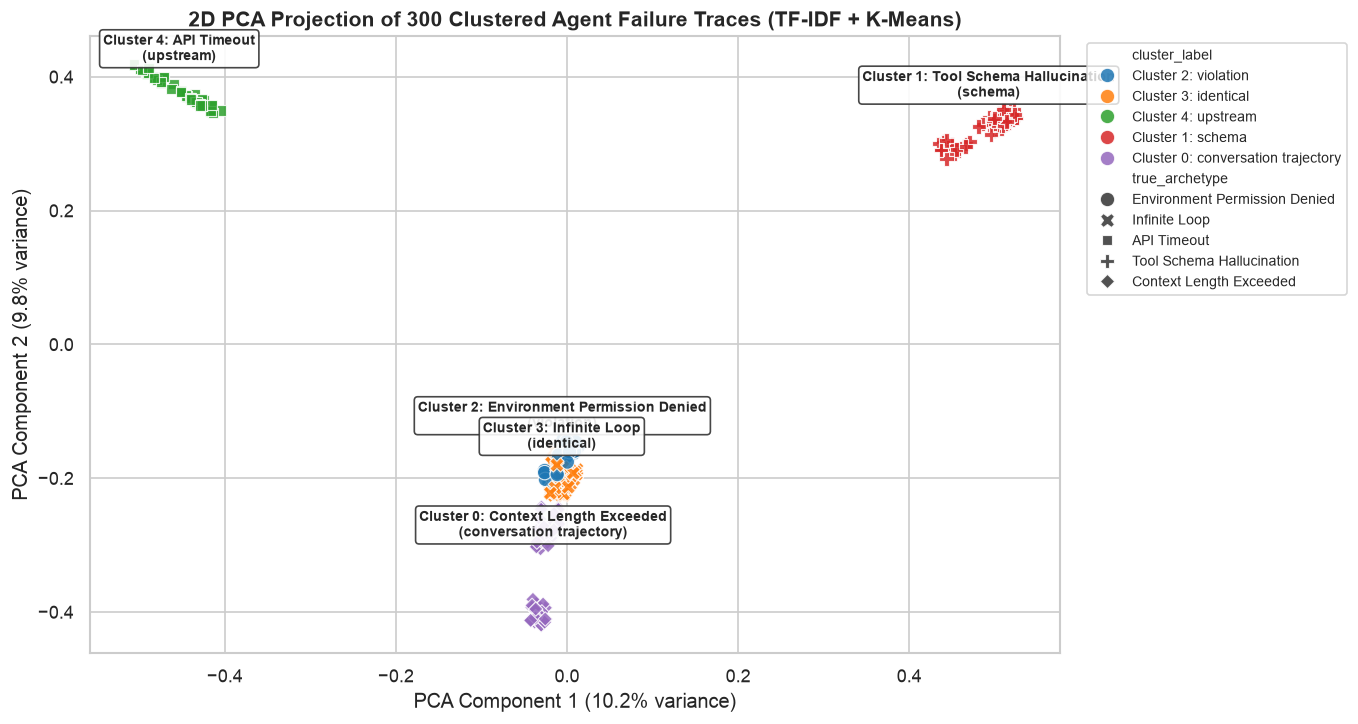

Saved interactive Plotly scatter plot to figures/ch08_interactive_failure_clusters.html


In [3]:
import plotly.express as px

logs_df = res["logs_df"]
summary_df = res["summary_df"]

# 1. Static High-DPI Scatter Plot with Centroid Diagnostic Labels
fig, ax = plt.subplots(figsize=(11.5, 6.2))
sns.scatterplot(
    data=logs_df,
    x="pca_x",
    y="pca_y",
    hue="cluster_label",
    style="true_archetype",
    s=75,
    alpha=0.85,
    palette="tab10",
    ax=ax,
)

for _, row in summary_df.iterrows():
    cid = row["cluster_id"]
    sub = logs_df[logs_df["cluster_id"] == cid]
    cx, cy = sub["pca_x"].mean(), sub["pca_y"].mean()
    ax.text(
        cx, cy + 0.04,
        f"Cluster {cid}: {row['dominant_archetype']}\n({row['top_keywords'].split(',')[0]})",
        ha="center", va="bottom", fontsize=8.5, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#333333", alpha=0.9),
    )

ax.set_title("2D PCA Projection of 300 Clustered Agent Failure Traces (TF-IDF + K-Means)", fontsize=12.5, fontweight="bold")
ax.set_xlabel(f"PCA Component 1 ({res['explained_variance_ratio'][0]:.1%} variance)")
ax.set_ylabel(f"PCA Component 2 ({res['explained_variance_ratio'][1]:.1%} variance)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8.5)

plt.tight_layout()
plt.savefig("figures/ch08_failure_trace_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Save Interactive Plotly HTML Scatter Plot
fig_plotly = px.scatter(
    logs_df,
    x="pca_x",
    y="pca_y",
    color="cluster_label",
    symbol="true_archetype",
    hover_data=["log_id", "tool_name", "true_archetype"],
    title="Interactive 2D Clustered Agent Failure Traces (Chapter 8)",
)
fig_plotly.write_html("figures/ch08_interactive_failure_clusters.html")
print("Saved interactive Plotly scatter plot to figures/ch08_interactive_failure_clusters.html")